# Phone Detection Dataset Exploration - COCO / YOLO

Notebook này chỉ tập trung vào dataset phone dạng object detection.

Nguồn chính:
- `backend/dataset/phone-yolo/` theo script `train_phone_yolo.py`.
- Các thư mục có chữ `phone` trong `backend/dataset/` hoặc `backend/driver_training/dataset/`.
- COCO JSON nếu dataset phone của bạn đang ở dạng COCO.
- YOLO label `.txt` nếu đã convert từ COCO/Roboflow/Kaggle sang YOLO.

`phone_data.csv` không phải dataset train phone; nó chỉ là log/runtime nên được để ở phần phụ lục cuối notebook.

In [9]:
from pathlib import Path
from collections import Counter
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from PIL import Image
except Exception:
    Image = None

plt.rcParams["figure.figsize"] = (10, 5)
random.seed(42)

## 1. Tìm đúng thư mục dataset phone

Cell này cố ý chỉ lấy thư mục có chữ `phone`, để tránh lôi nhầm dataset mắt/yawning/drowsy.

In [10]:
NOTEBOOK_DIR = Path.cwd()
BACKEND_CANDIDATES = [
    NOTEBOOK_DIR / ".." / "..",
    Path("../.."),
    Path("DiQuaMuaHaa/backend"),
]
BACKEND_DIR = next((p.resolve() for p in BACKEND_CANDIDATES if (p / "driver_training").exists()), None)
if BACKEND_DIR is None:
    raise FileNotFoundError("Không tìm thấy backend/driver_training")

OUT_DIR = (NOTEBOOK_DIR / "outputs" / "phone").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

preferred_roots = [
    BACKEND_DIR / "dataset" / "phone-yolo",
    BACKEND_DIR / "dataset" / "phone-using",
    BACKEND_DIR / "driver_training" / "dataset" / "phone-yolo",
]

scan_bases = [BACKEND_DIR / "dataset", BACKEND_DIR / "driver_training" / "dataset"]
phone_roots = []
for p in preferred_roots:
    if p.exists():
        phone_roots.append(p.resolve())
for base in scan_bases:
    if base.exists():
        for p in base.rglob("*"):
            if p.is_dir() and "phone" in p.name.lower():
                phone_roots.append(p.resolve())

# Deduplicate while keeping order.
seen = set()
phone_roots = [p for p in phone_roots if not (str(p) in seen or seen.add(str(p)))]

print("Backend:", BACKEND_DIR)
print("Phone dataset roots found:", len(phone_roots))
for p in phone_roots:
    print(" -", p)

if not phone_roots:
    print("Chưa thấy dataset phone local. Nếu bạn có COCO/YOLO ở chỗ khác, sửa phone_roots thủ công ở cell này.")

Backend: D:\deployweb\conghienmegrge\DiQuaMuaHaa\backend
Phone dataset roots found: 4
 - D:\deployweb\conghienmegrge\DiQuaMuaHaa\backend\dataset\phone-yolo
 - D:\deployweb\conghienmegrge\DiQuaMuaHaa\backend\dataset\phone-using
 - D:\deployweb\conghienmegrge\DiQuaMuaHaa\backend\dataset\phone-using\no_phone
 - D:\deployweb\conghienmegrge\DiQuaMuaHaa\backend\dataset\phone-using\phone


## 2. Inventory ảnh, YOLO label, COCO JSON

,kind,count
0,images,2568
1,yolo_labels,1096
2,coco_json,0
3,yaml,0


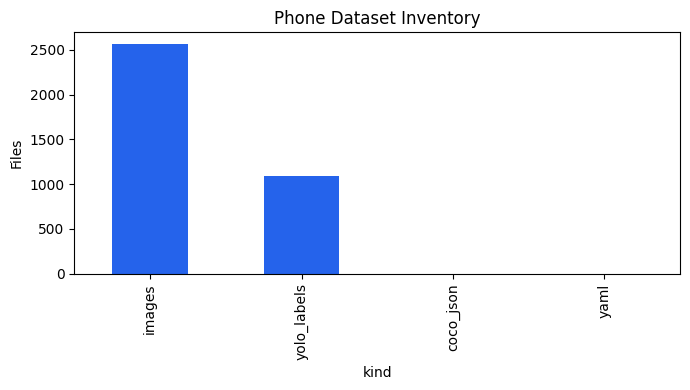

Sample images:
  D:\deployweb\conghienmegrge\DiQuaMuaHaa\backend\dataset\phone-yolo\images\train\-1100_png_jpg.rf.01f267c8ae808933099735585899aeb0.jpg
  D:\deployweb\conghienmegrge\DiQuaMuaHaa\backend\dataset\phone-yolo\images\train\-1117_png_jpg.rf.e438fa97bdcc0577a6fef8c79cd0591d.jpg
  D:\deployweb\conghienmegrge\DiQuaMuaHaa\backend\dataset\phone-yolo\images\train\-1130_png_jpg.rf.28a1e68ea4fea0298411b08247335fbb.jpg
  D:\deployweb\conghienmegrge\DiQuaMuaHaa\backend\dataset\phone-yolo\images\train\-1131_png_jpg.rf.56645462dcfc68a74a16fe16c9fb21fa.jpg
  D:\deployweb\conghienmegrge\DiQuaMuaHaa\backend\dataset\phone-yolo\images\train\-161_png_jpg.rf.8e79fe724ff8d08a13ead7480f29f3bc.jpg
Sample labels:
  D:\deployweb\conghienmegrge\DiQuaMuaHaa\backend\dataset\phone-yolo\labels\train\-1100_png_jpg.rf.01f267c8ae808933099735585899aeb0.txt
  D:\deployweb\conghienmegrge\DiQuaMuaHaa\backend\dataset\phone-yolo\labels\train\-1117_png_jpg.rf.e438fa97bdcc0577a6fef8c79cd0591d.txt
  D:\deployweb\cong

In [11]:
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_files = []
label_files = []
json_files = []
yaml_files = []

for root in phone_roots:
    for p in root.rglob("*"):
        if not p.is_file():
            continue
        suf = p.suffix.lower()
        if suf in image_exts:
            image_files.append(p)
        elif suf == ".txt" and "label" in str(p.parent).lower():
            label_files.append(p)
        elif suf == ".json":
            json_files.append(p)
        elif suf in {".yaml", ".yml"}:
            yaml_files.append(p)

inventory = pd.DataFrame([
    {"kind": "images", "count": len(image_files)},
    {"kind": "yolo_labels", "count": len(label_files)},
    {"kind": "coco_json", "count": len(json_files)},
    {"kind": "yaml", "count": len(yaml_files)},
])
display(inventory)

fig, ax = plt.subplots(figsize=(7, 4))
inventory.set_index("kind")["count"].plot(kind="bar", ax=ax, color="#2563eb")
ax.set_title("Phone Dataset Inventory")
ax.set_ylabel("Files")
plt.tight_layout()
fig.savefig(OUT_DIR / "01_phone_inventory.png", dpi=160)
plt.show()

print("Sample images:")
for p in image_files[:5]: print(" ", p)
print("Sample labels:")
for p in label_files[:5]: print(" ", p)
print("Sample json:")
for p in json_files[:5]: print(" ", p)

## 3. YOLO labels analysis

YOLO format: `class_id cx cy w h`, tọa độ normalized `[0,1]`.

YOLO annotations: 1744


,label_file,class_id,cx,cy,w,h,area
count,1744,1744.0,1744.000000,1744.000000,1744.000000,1744.000000,1744.000000
unique,1096,NaN,NaN,NaN,NaN,NaN,NaN
top,D:\deployweb\conghienmegrge\DiQuaMuaHaa\backen...,NaN,NaN,NaN,NaN,NaN,NaN
freq,25,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.0,0.507028,0.509336,0.376844,0.508760,0.227951
std,NaN,0.0,0.192629,0.143551,0.255146,0.266961,0.211842
min,NaN,0.0,0.011111,0.000000,0.003125,0.002498,0.000122
25%,NaN,0.0,0.406771,0.464062,0.187500,0.296484,0.062409
50%,NaN,0.0,0.500000,0.503125,0.314063,0.504687,0.162810
75%,NaN,0.0,0.620508,0.574219,0.558496,0.731250,0.335023


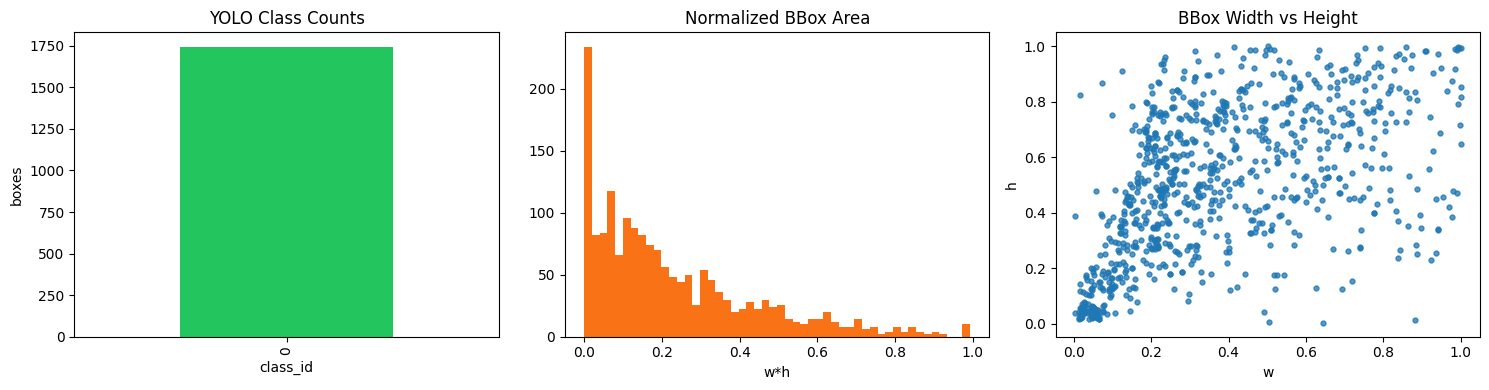

In [12]:
def parse_yolo_label(path):
    rows = []
    for line in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        try:
            cls, cx, cy, w, h = parts[:5]
            rows.append({
                "label_file": path,
                "class_id": int(float(cls)),
                "cx": float(cx),
                "cy": float(cy),
                "w": float(w),
                "h": float(h),
            })
        except ValueError:
            continue
    return rows

yolo_rows = []
for p in label_files:
    yolo_rows.extend(parse_yolo_label(p))

yolo_df = pd.DataFrame(yolo_rows)
print("YOLO annotations:", len(yolo_df))
if len(yolo_df):
    yolo_df["area"] = yolo_df["w"] * yolo_df["h"]
    display(yolo_df.describe(include="all"))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    yolo_df["class_id"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#22c55e")
    axes[0].set_title("YOLO Class Counts")
    axes[0].set_xlabel("class_id")
    axes[0].set_ylabel("boxes")
    axes[1].hist(yolo_df["area"], bins=50, color="#f97316")
    axes[1].set_title("Normalized BBox Area")
    axes[1].set_xlabel("w*h")
    axes[2].scatter(yolo_df["w"], yolo_df["h"], s=12, alpha=0.5)
    axes[2].set_title("BBox Width vs Height")
    axes[2].set_xlabel("w")
    axes[2].set_ylabel("h")
    plt.tight_layout()
    fig.savefig(OUT_DIR / "02_yolo_bbox_stats.png", dpi=160)
    plt.show()
else:
    print("Không có YOLO label trong phone roots.")

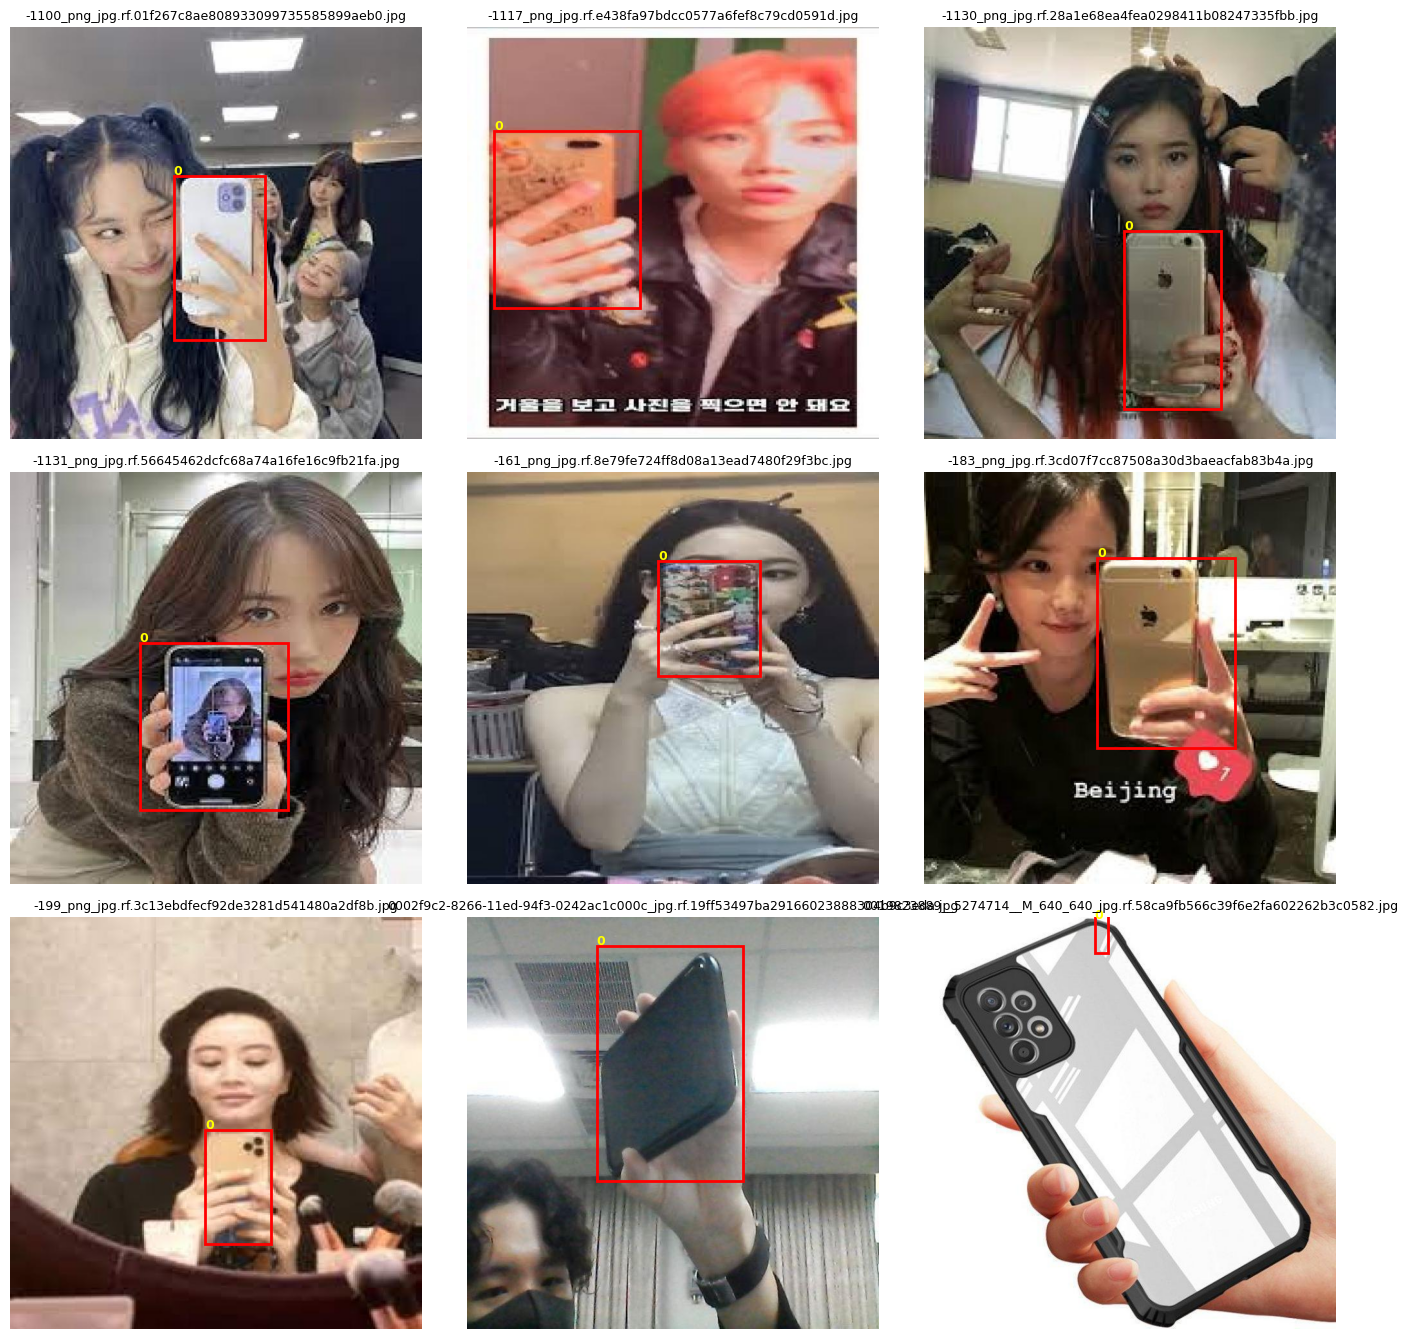

In [13]:
def find_image_for_label(label_path):
    stem = label_path.stem
    candidates = []
    for img_dir in [label_path.parent.parent / "images", label_path.parent.parent.parent / "images" / label_path.parent.name, label_path.parent]:
        for ext in image_exts:
            candidates.append(img_dir / f"{stem}{ext}")
    for c in candidates:
        if c.exists():
            return c
    matches = [p for p in image_files if p.stem == stem]
    return matches[0] if matches else None

if len(yolo_df) and Image is not None:
    sample_labels = list(yolo_df["label_file"].drop_duplicates())[:9]
    n = len(sample_labels)
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4.5 * rows))
    axes = np.asarray(axes).ravel()
    for ax, label_path in zip(axes, sample_labels):
        img_path = find_image_for_label(label_path)
        anns = yolo_df[yolo_df["label_file"] == label_path]
        if img_path and img_path.exists():
            im = Image.open(img_path).convert("RGB")
            W, H = im.size
            ax.imshow(im)
            for _, a in anns.iterrows():
                x = (a.cx - a.w / 2) * W
                y = (a.cy - a.h / 2) * H
                w = a.w * W
                h = a.h * H
                ax.add_patch(plt.Rectangle((x, y), w, h, fill=False, color="red", lw=2))
                ax.text(x, max(0, y - 3), str(a.class_id), color="yellow", fontsize=9, weight="bold")
            ax.set_title(img_path.name, fontsize=9)
        else:
            ax.text(0.5, 0.5, f"image not found\n{label_path.name}", ha="center")
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    fig.savefig(OUT_DIR / "03_yolo_sample_phone_boxes.png", dpi=160)
    plt.show()
elif len(yolo_df):
    print("PIL chưa import được nên không vẽ sample image.")

## 4. COCO JSON analysis

Nếu phone dataset của bạn còn ở COCO format, cell này đọc `images/categories/annotations` và vẽ bbox.

In [14]:
def load_coco(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    cats = {c["id"]: c.get("name", str(c["id"])) for c in data.get("categories", [])}
    imgs = {img["id"]: img for img in data.get("images", [])}
    anns = data.get("annotations", [])
    return data, cats, imgs, anns

coco_candidates = []
for p in json_files:
    try:
        with open(p, "r", encoding="utf-8") as f:
            d = json.load(f)
        if all(k in d for k in ["images", "annotations", "categories"]):
            coco_candidates.append(p)
    except Exception:
        pass

print("COCO JSON candidates:", len(coco_candidates))
for p in coco_candidates[:10]:
    print(" -", p)

coco_path = coco_candidates[0] if coco_candidates else None
if coco_path:
    data, cats, imgs, anns = load_coco(coco_path)
    print("Using:", coco_path)
    print("images", len(imgs), "annotations", len(anns), "categories", cats)
    rows = []
    for a in anns:
        x, y, w, h = a.get("bbox", [np.nan] * 4)
        rows.append({"category": cats.get(a.get("category_id"), str(a.get("category_id"))), "w": w, "h": h, "area": w * h, "image_id": a.get("image_id")})
    coco_df = pd.DataFrame(rows)
    display(coco_df.describe(include="all"))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    coco_df["category"].value_counts().plot(kind="bar", ax=axes[0], color="#6366f1")
    axes[0].set_title("COCO Category Counts")
    axes[1].hist(coco_df["area"].dropna(), bins=50, color="#f97316")
    axes[1].set_title("COCO BBox Area")
    axes[2].scatter(coco_df["w"], coco_df["h"], s=12, alpha=0.5)
    axes[2].set_title("COCO BBox W vs H")
    axes[2].set_xlabel("w")
    axes[2].set_ylabel("h")
    plt.tight_layout()
    fig.savefig(OUT_DIR / "04_coco_bbox_stats.png", dpi=160)
    plt.show()
else:
    print("Không tìm thấy COCO JSON trong phone roots.")

COCO JSON candidates: 0
Không tìm thấy COCO JSON trong phone roots.


In [15]:
def find_image_for_coco(coco_json_path, file_name):
    candidates = [
        coco_json_path.parent / file_name,
        coco_json_path.parent / "images" / file_name,
        coco_json_path.parent.parent / "images" / file_name,
        coco_json_path.parent.parent / "train" / "images" / file_name,
        coco_json_path.parent.parent / "valid" / "images" / file_name,
    ]
    for c in candidates:
        if c.exists():
            return c
    matches = [p for p in image_files if p.name == Path(file_name).name]
    return matches[0] if matches else None

if coco_path and Image is not None and len(anns):
    sample_anns = random.sample(anns, min(9, len(anns)))
    fig, axes = plt.subplots(3, 3, figsize=(14, 12))
    axes = axes.ravel()
    for ax, ann in zip(axes, sample_anns):
        img = imgs.get(ann.get("image_id"))
        img_path = find_image_for_coco(coco_path, img.get("file_name", "")) if img else None
        if img_path and img_path.exists():
            im = Image.open(img_path).convert("RGB")
            ax.imshow(im)
            x, y, w, h = ann.get("bbox", [0, 0, 0, 0])
            ax.add_patch(plt.Rectangle((x, y), w, h, fill=False, color="red", lw=2))
            ax.set_title(f"{cats.get(ann.get('category_id'), 'object')} | {img_path.name}", fontsize=9)
        else:
            ax.text(0.5, 0.5, "image not found", ha="center")
        ax.axis("off")
    plt.tight_layout()
    fig.savefig(OUT_DIR / "05_coco_sample_phone_boxes.png", dpi=160)
    plt.show()

## 5. Phụ lục: `phone_data.csv` chỉ là log/runtime

Phần này không dùng để train COCO/YOLO. Nó chỉ giúp biết log demo có dữ liệu hay không.

In [16]:
phone_csv = BACKEND_DIR / "phone_data.csv"
if phone_csv.exists():
    phone_df = pd.read_csv(phone_csv)
    print(phone_csv)
    print("shape:", phone_df.shape)
    display(phone_df.head())
    if len(phone_df) == 0:
        print("File này hiện chỉ có header, không phải dataset train phone.")
else:
    print("Không có phone_data.csv")

D:\deployweb\conghienmegrge\DiQuaMuaHaa\backend\phone_data.csv
shape: (0, 3)


,phone,timestamp,raw_text


File này hiện chỉ có header, không phải dataset train phone.


## Kết luận cần nhìn

- Nếu ảnh sample không phải điện thoại, nghĩa là `phone_roots` đang trỏ sai.
- Nếu bbox full frame (`w=1`, `h=1`) quá nhiều, model chỉ học frame-level cue chứ không học vị trí phone thật.
- Nếu dùng COCO pretrained không fine-tune, nên test confidence/bbox trên webcam cabin thật, vì COCO cell phone thường yếu với góc lái xe.